# 05 · Test evaluation: Sep 17–30, 2026

**Input:** two forecast files from `04`: the final forecast (`reports/forecast_2026-09-17_to_2026-09-30_linear_regression.csv`) and the same window forecast by every comparison method (`reports/forecast_2026-09-17_to_2026-09-30_comparison_methods.csv`), plus their validation scores (`reports/validation_summary.csv`).
**Output:** `data/external/rdu_obs_2026-09-17_to_2026-09-30.csv` (observations of the test window), the test scores and `reports/figures/05_*.png`.

This notebook only scores forecasts; it trains nothing. The observations of the test window are downloaded here for scoring only and are never an input to any model; they are kept in `data/external/`, separate from the training data in `data/raw/`.

## 1. Settings and integrity check

The final forecast was saved and its SHA-256 checksum recorded on Oct 4, 2026 (03:30 UTC), before any observation from Sep 17–30 was downloaded. The checks below confirm that the frozen file is unchanged and that `04` reproduces it exactly, in both of its output files.

In [1]:
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

current_dir = Path.cwd().resolve()
PROJECT_ROOT = next(
    folder for folder in [current_dir, *current_dir.parents]
    if (folder / "notebooks").is_dir() and (folder / "requirements.txt").is_file()
)
FORECAST_FILE = PROJECT_ROOT / "reports" / "forecast_2026-09-17_to_2026-09-30_linear_regression.csv"
COMPARISON_FILE = PROJECT_ROOT / "reports" / "forecast_2026-09-17_to_2026-09-30_comparison_methods.csv"
VALIDATION_FILE = PROJECT_ROOT / "reports" / "validation_summary.csv"
FROZEN_FILE = PROJECT_ROOT / "scripts" / "results" / "final_forecast_M14.csv"   # frozen before any test data was seen
FROZEN_HASH = PROJECT_ROOT / "scripts" / "results" / "final_forecast_M14.sha256"
TEST_OBS_FILE = PROJECT_ROOT / "data" / "external" / "rdu_obs_2026-09-17_to_2026-09-30.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"

NY = "America/New_York"
TEST_START = pd.Timestamp("2026-09-17", tz=NY)
TEST_END = pd.Timestamp("2026-10-01", tz=NY)  # exclusive
NOAA_URL = ("https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/"
            "by-year/2026/psv/GHCNh_USW00013722_2026.psv")


def save_fig(fig, name):
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / f"05_{name}.png", dpi=150, bbox_inches="tight")


forecast = pd.read_csv(FORECAST_FILE)
comparison = pd.read_csv(COMPARISON_FILE)
frozen = pd.read_csv(FROZEN_FILE)
recorded_hash, frozen_at = FROZEN_HASH.read_text().split("\n")[0].split()[0], FROZEN_HASH.read_text().split("\n")[1]
same_hours = lambda frame: frame["hour_local"].tolist() == frozen["hour_local"].tolist()
checks = {
    "frozen file unchanged since it was locked": hashlib.sha256(FROZEN_FILE.read_bytes()).hexdigest() == recorded_hash,
    "04 forecast = frozen forecast": same_hours(forecast) and np.allclose(forecast["forecast_deg_c"], frozen["temperature_forecast_c"]),
    "04 comparison file: final model = frozen forecast": same_hours(comparison)
                                                         and np.allclose(comparison["lr_final"], frozen["temperature_forecast_c"]),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values())
print(f"Forecast: {len(forecast)} hours, {forecast['hour_local'].iloc[0]} -> {forecast['hour_local'].iloc[-1]}; {frozen_at}")

,passed
frozen file unchanged since it was locked,True
04 forecast = frozen forecast,True
04 comparison file: final model = frozen forecast,True


Forecast: 336 hours, 2026-09-17 00:00 -> 2026-09-30 23:00; frozen at 2026-10-04T03:30:52Z (before downloading Sep 17-30 observations)


### 1.1 How the final model was chosen

The final model (called M14 in `scripts/`) was chosen on validation data and frozen before any test observation was seen. All times Eastern, 2026:

| When | What | Record |
|---|---|---|
| Oct 3, 23:21 | 23 candidate models scored on the two validation folds; M14 has the lowest MAE over both folds (2.041 °C; next best 2.069 °C) | `scripts/results/mos_scores.csv` |
| Oct 3, 23:22 | Final forecast made with M14 | `scripts/results/final_forecast_M14.csv` |
| Oct 3, 23:30:52 | Forecast frozen: SHA-256 checksum recorded (= Oct 4, 03:30:52 UTC) | `scripts/results/final_forecast_M14.sha256` |
| Oct 3, 23:32 | Sep 17–30 observations downloaded; all 23 candidates scored on the test window | `scripts/results/test_scores.csv` |
| Oct 3, 23:46 | Extra check on six 2026 windows (no test data; the model was not changed) | `scripts/results/extra_windows_2026_mae.csv` |
| Oct 5 | Notebooks reorganised; the NOAA-only steps, GFS and the y = temperature variant added as after-the-fact comparisons, to explain the design | `04`, this notebook |

- On the test window, M14 is **not** the best of the 23 candidates: it ranks 6th (2.694 °C, against 2.666 °C for the best one, M12, on the 322 hours observed at the time). Choosing on the test scores would have picked M12.
- **Data availability.** The ECMWF 12z run of Sep 16 used for the forecast was uploaded at 19:34 UTC, 8.4 hours before the cutoff (GFS: 17:09 UTC). Two older ECMWF runs used in training (2024-09-17, 2025-02-24) were uploaded later than the backtest assumes, but more than a year before the cutoff, so they do not break the data rule (`docs/data_checks.md`).

## 2. Observations of the test window

Same selection (FM15 reports at minute :51, labelled with their hour) and the same temperature cleaning rules as `02`. NOAA's yearly file can lag by a few hours, so the last hours of Sep 30 may still be missing.

In [2]:
noaa = pd.read_csv(NOAA_URL, sep="|", low_memory=False)
noaa = noaa[noaa["temperature_Report_Type"].eq("FM15") & noaa["Minute"].eq(51)].copy()
noaa.index = pd.DatetimeIndex(pd.to_datetime(noaa["DATE"], utc=True).dt.floor("h"), name="hour_utc")  # hh:51 -> hh
noaa = noaa[~noaa.index.duplicated()].sort_index()

# Same temperature cleaning as 02 (one day of margin so the spike checks have neighbours)
grid = pd.date_range((TEST_START - pd.Timedelta(days=1)).tz_convert("UTC"), (TEST_END + pd.Timedelta(days=1)).tz_convert("UTC"),
                     freq="h", inclusive="left", name="hour_utc")
obs = noaa.reindex(grid)
ISD_SOURCES = {"313", "314", "315", "322", "335", "343", "344", "346"}
LEGACY_SOURCES = {"220", "221", "222", "223", "347", "348"}
LIMITS = {"temperature": (-30, 45), "dew_point_temperature": (-40, 35), "altimeter": (950, 1060)}
code = lambda s: s.astype("string").str.replace(r"\.0$", "", regex=True).fillna("")


def bad_quality(v):
    source, quality = code(obs[f"{v}_Source_Code"]), code(obs[f"{v}_Quality_Code"])
    return ((source.isin(ISD_SOURCES) & quality.isin({"2", "3", "6", "7"}))
            | (source.isin(LEGACY_SOURCES) & quality.isin({"2", "3", "5"})) | quality.str.contains(r"[a-z]", regex=True))


def spike_size(x):
    jump_in, jump_out = x - x.shift(1), x - x.shift(-1)
    return np.minimum(jump_in.abs(), jump_out.abs()).where(np.sign(jump_in) == np.sign(jump_out), 0)


values = {v: pd.to_numeric(obs[v], errors="coerce") for v in LIMITS}
screened = {v: values[v].mask(bad_quality(v) | ~values[v].between(*LIMITS[v])) for v in LIMITS}
corrupted = ((spike_size(screened["temperature"]) > 4).astype(int) + (spike_size(screened["dew_point_temperature"]) > 5).astype(int)
             + (spike_size(screened["altimeter"]) > 3).astype(int)) >= 2
rejected = (bad_quality("temperature") | ~values["temperature"].between(*LIMITS["temperature"]) | corrupted
            | (spike_size(screened["temperature"]) > 8)) & values["temperature"].notna()

test_hours = grid[(grid >= TEST_START) & (grid < TEST_END)]
actual = pd.DataFrame({"hour_local": test_hours.tz_convert(NY).strftime("%Y-%m-%d %H:%M"),
                       "observed_deg_c": values["temperature"].mask(rejected).reindex(test_hours)}, index=test_hours)
TEST_OBS_FILE.parent.mkdir(parents=True, exist_ok=True)
actual.to_csv(TEST_OBS_FILE, index_label="hour_utc")
print(f"Saved {TEST_OBS_FILE.relative_to(PROJECT_ROOT)}: {actual['observed_deg_c'].notna().sum()} of {len(actual)} hours observed, "
      f"{int(rejected.reindex(test_hours).sum())} rejected; last observation {actual.dropna().iloc[-1]['hour_local']}")

Saved data/external/rdu_obs_2026-09-17_to_2026-09-30.csv: 322 of 336 hours observed, 0 rejected; last observation 2026-09-30 09:00


## 3. Scores

Every method is scored on the same hours (those with an observation). Each method has a **role**:

- *heuristic baseline*: persistence and the historical average;
- *raw forecast*: a weather model's forecast, used as is;
- *final model, frozen before the test*: the only forecast submitted;
- *post-hoc comparison (added Oct 5)*: added after the test scores were known, to explain the design (`04`); none of them had a part in choosing the model.

This is a single 14-day forecast, so the test numbers are much noisier than the validation in `04` (105 scored forecasts over the two folds).

In [3]:
FINAL = "LR, NOAA + ECMWF (final)"
METHODS = {  # name: (column in the comparison file, role)
    "Persistence": ("persistence", "heuristic baseline"),
    "Historical average": ("historical_average", "heuristic baseline"),
    "LR, raw NOAA values": ("lr_raw_noaa", "post-hoc comparison (added Oct 5)"),
    "LR, NOAA anomalies": ("lr_noaa_anomalies", "post-hoc comparison (added Oct 5)"),
    "ECMWF raw": ("ecmwf_raw", "raw forecast"),
    "ECMWF lagged mean": ("ecmwf_lagged_mean", "raw forecast"),
    "GFS raw": ("gfs_raw", "raw forecast, post-hoc (added Oct 5)"),
    "LR, NOAA + ECMWF, y = temperature": ("lr_temperature_target", "post-hoc comparison (added Oct 5)"),
    FINAL: ("lr_final", "final model, frozen before the test"),
}
table = comparison.set_index("hour_local")
table["observed"] = actual.set_index("hour_local")["observed_deg_c"]
scored = table.dropna(subset=["observed"])
errors = pd.DataFrame({name: scored["observed"] - scored[column] for name, (column, _) in METHODS.items()})

test_mae = errors.abs().mean()
scores = pd.DataFrame({
    "role": [role for _, role in METHODS.values()],
    "MAE": test_mae,
    "RMSE": np.sqrt((errors ** 2).mean()),
    "bias (obs - forecast)": errors.mean(),
    "% vs hist. avg": 100 * (1 - test_mae / test_mae["Historical average"]),
    "final LR: % lower MAE than this": 100 * (1 - test_mae[FINAL] / test_mae),
})
print(f"Scored hours: {len(scored)} of {len(table)}")
display(scores.round(2))

by_day = errors.abs().groupby(scored["lead_day"].to_numpy()).mean().T
by_day.columns.name = "forecast day"
display(by_day.round(2))

Scored hours: 322 of 336


,role,MAE,RMSE,bias (obs - forecast),% vs hist. avg,final LR: % lower MAE than this
Persistence,heuristic baseline,4.06,4.96,-1.36,-11.55,33.64
Historical average,heuristic baseline,3.64,4.42,-0.22,0.00,25.98
"LR, raw NOAA values",post-hoc comparison (added Oct 5),3.53,4.40,-0.97,2.98,23.70
"LR, NOAA anomalies",post-hoc comparison (added Oct 5),3.60,4.44,-0.72,1.07,25.18
ECMWF raw,raw forecast,3.27,4.07,-0.03,10.16,17.61
ECMWF lagged mean,raw forecast,2.83,3.68,-1.00,22.21,4.85
GFS raw,"raw forecast, post-hoc (added Oct 5)",4.03,5.19,0.90,-10.73,33.15
"LR, NOAA + ECMWF, y = temperature",post-hoc comparison (added Oct 5),2.70,3.64,-1.15,25.72,0.35
"LR, NOAA + ECMWF (final)","final model, frozen before the test",2.69,3.67,-1.31,25.98,0.00


forecast day,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Persistence,2.52,4.50,2.95,2.80,4.00,2.92,6.64,7.21,6.95,5.23,3.56,2.85,1.95,0.95
Historical average,3.42,5.01,3.67,3.77,4.52,1.72,5.37,5.84,5.63,4.05,2.29,1.88,1.24,1.06
"LR, raw NOAA values",3.03,4.05,2.77,2.78,3.69,1.59,6.24,6.67,6.27,4.44,2.57,1.80,0.95,1.26
"LR, NOAA anomalies",3.00,4.44,3.17,3.28,4.02,1.75,5.86,6.35,6.10,4.31,2.74,1.93,0.81,1.34
ECMWF raw,1.40,1.29,1.71,1.66,1.67,1.57,6.45,6.69,4.12,3.52,3.72,3.73,5.33,2.43
ECMWF lagged mean,1.20,1.44,2.35,1.80,1.77,1.38,6.37,6.54,5.15,3.69,2.13,1.40,2.26,1.21
GFS raw,0.53,1.47,2.10,1.47,1.57,1.33,2.42,7.49,6.92,4.48,5.33,6.95,8.72,7.84
"LR, NOAA + ECMWF, y = temperature",1.09,1.22,2.01,1.60,1.73,1.41,6.51,6.76,5.25,3.27,1.86,1.14,1.97,1.12
"LR, NOAA + ECMWF (final)",1.15,1.17,1.99,1.62,1.78,1.32,6.43,6.68,5.33,3.45,1.79,1.36,1.48,1.44


### 3.1 Validation and test side by side

% lower MAE than the historical average, for the methods that have all four numbers (validation from `04`). The test is one forecast; the validation numbers average many.

In [4]:
validation = pd.read_csv(VALIDATION_FILE, index_col="method")
column_of = {name: column for name, (column, _) in METHODS.items()}
KEY = ["Historical average", "LR, NOAA anomalies", "ECMWF raw", "ECMWF lagged mean", FINAL]
side_by_side = pd.DataFrame({
    "Fold 1 (2025)": validation["fold1_pct_vs_hist_avg"],
    "Fold 2 (2026)": validation["fold2_pct_vs_hist_avg"],
    "six 2026 windows": validation["windows_pct_vs_hist_avg"],
}).loc[[column_of[name] for name in KEY]].set_axis(KEY)
side_by_side["test (Sep 17-30)"] = scores.loc[KEY, "% vs hist. avg"]
display(side_by_side.round(0))

,Fold 1 (2025),Fold 2 (2026),six 2026 windows,test (Sep 17-30)
Historical average,0.0,0.0,0.0,0.0
"LR, NOAA anomalies",-6.0,9.0,2.0,1.0
ECMWF raw,16.0,19.0,25.0,10.0
ECMWF lagged mean,21.0,25.0,23.0,22.0
"LR, NOAA + ECMWF (final)",24.0,29.0,24.0,26.0


## 4. Forecast vs. observations

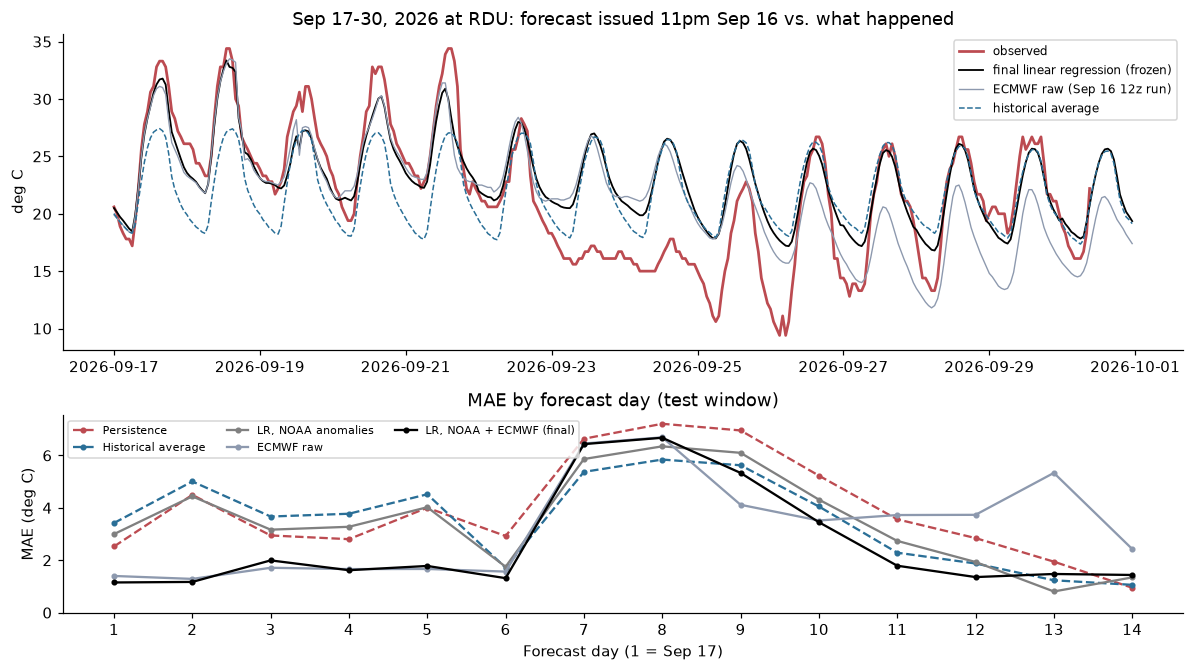

date,2026-09-17,2026-09-18,2026-09-19,2026-09-20,2026-09-21,2026-09-22,2026-09-23,2026-09-24,2026-09-25,2026-09-26,2026-09-27,2026-09-28,2026-09-29,2026-09-30
observed,25.7,27.5,26.1,26.0,26.6,22.4,16.5,16.0,16.2,17.9,19.6,20.3,22.5,17.7
lr_final,25.0,26.6,24.2,25.0,25.2,23.6,23.0,22.6,21.6,20.9,20.9,21.0,21.1,21.2
ecmwf_raw,24.6,26.6,24.5,25.3,25.2,23.7,23.0,22.7,20.3,18.6,16.6,16.6,17.2,17.8
historical_average,22.6,22.5,22.4,22.2,22.1,22.0,21.9,21.8,21.8,21.8,21.9,21.7,21.3,20.9


In [5]:
when = pd.to_datetime(table.index)
fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), gridspec_kw={"height_ratios": [1.6, 1]})
axes[0].plot(when, table["observed"], color="#bc4b51", linewidth=1.8, label="observed")
axes[0].plot(when, table["lr_final"], color="black", linewidth=1.2, label="final linear regression (frozen)")
axes[0].plot(when, table["ecmwf_raw"], color="#8d99ae", linewidth=0.9, label="ECMWF raw (Sep 16 12z run)")
axes[0].plot(when, table["historical_average"], color="#2a6f97", linestyle="--", linewidth=1, label="historical average")
axes[0].set(title="Sep 17-30, 2026 at RDU: forecast issued 11pm Sep 16 vs. what happened", ylabel="deg C")
axes[0].legend(fontsize=8)
styles = {"Persistence": ("#bc4b51", "--"), "Historical average": ("#2a6f97", "--"), "LR, NOAA anomalies": ("grey", "-"),
          "ECMWF raw": ("#8d99ae", "-"), FINAL: ("black", "-")}
for name, (color, line) in styles.items():
    axes[1].plot(by_day.columns, by_day.loc[name], color=color, linestyle=line, marker="o", markersize=3, label=name)
axes[1].set(title="MAE by forecast day (test window)", xlabel="Forecast day (1 = Sep 17)", ylabel="MAE (deg C)", ylim=(0, None))
axes[1].set_xticks(range(1, 15))
axes[1].legend(fontsize=7, ncol=3)
fig.tight_layout()
save_fig(fig, "test_forecast_vs_observed")
plt.show()

daily = table.assign(date=table.index.str[:10]).groupby("date")[["observed", "lr_final", "ecmwf_raw", "historical_average"]].mean()
display(daily.round(1).T)

## 5. The cold snap of Sep 23–25

On Sep 23–25 (forecast days 7–9) the daily mean temperature fell from about 26 °C to about 16 °C. The table shows how every method did on those three days and on the other eleven. The second column is descriptive only: the score of the forecast is the one over all hours in Section 3.

In [6]:
cold = scored.index.str[:10].isin(["2026-09-23", "2026-09-24", "2026-09-25"])
display(pd.DataFrame({"MAE, Sep 23-25": errors[cold].abs().mean(),
                      "MAE, other days (descriptive)": errors[~cold].abs().mean()}).round(2))
final_error = errors[FINAL].abs()
print(f"Sep 23-25: {cold.sum()} of {len(scored)} scored hours ({100 * cold.mean():.0f}%), "
      f"but {100 * final_error[cold].sum() / final_error.sum():.0f}% of the final model's total absolute error")
print("ECMWF raw, MAE on forecast days 7, 8, 9: " + ", ".join(f"{by_day.loc['ECMWF raw', day]:.2f}" for day in (7, 8, 9)))

,"MAE, Sep 23-25","MAE, other days (descriptive)"
Persistence,6.93,3.23
Historical average,5.61,3.07
"LR, raw NOAA values",6.39,2.71
"LR, NOAA anomalies",6.10,2.88
ECMWF raw,5.75,2.56
ECMWF lagged mean,6.02,1.91
GFS raw,5.61,3.58
"LR, NOAA + ECMWF, y = temperature",6.17,1.71
"LR, NOAA + ECMWF (final)",6.15,1.70


Sep 23-25: 72 of 322 scored hours (22%), but 51% of the final model's total absolute error
ECMWF raw, MAE on forecast days 7, 8, 9: 6.45, 6.69, 4.12


## 6. Summary

All numbers are on the 322 of 336 hours that NOAA had published when this notebook was run (the last hours of Sep 30 were still missing).

- **The frozen final model**: MAE 2.69 °C. That is 26% lower than the historical average (3.64 °C), 34% lower than persistence (4.06 °C), 18% lower than raw ECMWF (3.27 °C) and 5% lower than the ECMWF lagged mean (2.83 °C).
- **Consistent with validation**: 26% better than the historical average on the test, against 24% and 29% on the two validation folds and 24% on the six 2026 windows.
- **The steps of `04` hold on the test**: the NOAA-only models stay close to the historical average (3% and 1% better), raw ECMWF is 10% better, its lagged mean 22% and the final model 26%.
- **GFS** is worse than ECMWF here too (4.03 °C against 3.27 °C), and even worse than the historical average.
- **The y = temperature variant** scores 2.70 °C on this single forecast, practically the same as the final model; on validation, predicting the departure from the historical average was better (2.03 against 2.11 °C over both folds).
- **The cold snap of Sep 23–25** covers 22% of the scored hours but 51% of the final model's total absolute error. Every method had an MAE between 5.6 and 6.9 °C on those three days, raw ECMWF included: none of them forecast it from 11pm Sep 16.
- The final model was frozen before the test; every other model learned from data before Sep 17 as well, but the post-hoc ones were added after the test scores were known and played no part in the choice.